In [100]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────

import numpy as np                 # numerical operations
import pandas as pd                # dataset handling
import matplotlib.pyplot as plt    # plotting graphs

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [102]:
# ─────────────────────────────────────────────
# PERSONALIZED PARAMETERS
# ─────────────────────────────────────────────

ROLL = "102317087"

digits = [int(d) for d in ROLL]

# WHY: number of past values model sees
window_size = (sum(digits)) % 10 + 8   # = 17

# WHY: how many future values to predict
prediction_horizon = (int(ROLL[-2:])) % 3 + 1   # = 1

# WHY: model memory size
hidden_size = (int(ROLL[:3])) % 16 + 8   # = 14

print("Window Size:", window_size)
print("Prediction Horizon:", prediction_horizon)
print("Hidden Size:", hidden_size)
print("Model: Custom GRU (ODD roll number)")

Window Size: 17
Prediction Horizon: 1
Hidden Size: 14
Model: Custom GRU (ODD roll number)


In [104]:
# ─────────────────────────────────────────────
# WINDOWING
# ─────────────────────────────────────────────

def create_windows(data, window_size, horizon):
    """
    WHY:
    Convert time-series → supervised learning

    Example:
    [10,20,30,40]

    window=3 → X=[10,20,30], y=[40]
    """

    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):

        # past values
        X.append(data[i:i+window_size])

        # next value
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

In [110]:
# ─────────────────────────────────────────────
# LOAD TEMPERATURE DATASET
# ─────────────────────────────────────────────

# CLEAN DATASET (no error)
df = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
)

print(df.head())
print(df.columns)

# Use temperature column
data = df["Temp"].values.reshape(-1, 1)

         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
Index(['Date', 'Temp'], dtype='object')


In [112]:
# ─────────────────────────────────────────────
# NORMALIZATION
# ─────────────────────────────────────────────

scaler = MinMaxScaler()
data = scaler.fit_transform(data).flatten()

In [114]:
# ─────────────────────────────────────────────
# TRAIN TEST SPLIT
# ─────────────────────────────────────────────

split = int(0.8 * len(data))

train_data = data[:split]
test_data  = data[split:]

In [116]:
# ─────────────────────────────────────────────
# DATA PREPARATION
# ─────────────────────────────────────────────

def prepare_data(data, window):

    X, y = create_windows(data, window, prediction_horizon)

    X = torch.FloatTensor(X).unsqueeze(-1)
    y = torch.FloatTensor(y)

    return DataLoader(TensorDataset(X, y), batch_size=32, shuffle=False)

In [118]:
# ─────────────────────────────────────────────
# MLP MODEL
# ─────────────────────────────────────────────

class MLP(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, prediction_horizon)
        )

    def forward(self, x):
        return self.net(x)

In [120]:
# ─────────────────────────────────────────────
# CUSTOM GRU
# ─────────────────────────────────────────────

class CustomGRU(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden_size = hidden_size

        self.Wz = nn.Linear(1 + hidden_size, hidden_size)
        self.Wr = nn.Linear(1 + hidden_size, hidden_size)
        self.Wh = nn.Linear(1 + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):

        batch_size = x.size(0)
        h = torch.zeros(batch_size, hidden_size)

        for t in range(x.size(1)):

            combined = torch.cat([x[:, t, :], h], dim=1)

            z = torch.sigmoid(self.Wz(combined))
            r = torch.sigmoid(self.Wr(combined))

            combined_r = torch.cat([x[:, t, :], r * h], dim=1)
            h_new = torch.tanh(self.Wh(combined_r))

            h = (1 - z) * h + z * h_new

        return self.fc(h)

In [122]:
# ─────────────────────────────────────────────
# LSTM
# ─────────────────────────────────────────────

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [124]:
# ─────────────────────────────────────────────
# TRANSFORMER
# ─────────────────────────────────────────────

class TransformerModel(nn.Module):

    def __init__(self, seq_len):
        super().__init__()

        layer = nn.TransformerEncoderLayer(d_model=1, nhead=1, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)

        self.fc = nn.Linear(seq_len, prediction_horizon)

    def forward(self, x):
        out = self.transformer(x)
        out = out.squeeze(-1)
        return self.fc(out)

In [126]:
# ─────────────────────────────────────────────
# TRAIN FUNCTION
# ─────────────────────────────────────────────

def train_model(model, loader):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(10):

        total_loss = 0

        for X, y in loader:

            optimizer.zero_grad()

            pred = model(X)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg = total_loss / len(loader)
        losses.append(avg)

        print(f"Epoch {epoch+1}: Loss = {avg:.4f}")

    return losses

In [128]:
# ─────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────

def evaluate(model, loader):

    preds, actual = [], []

    with torch.no_grad():
        for X, y in loader:
            p = model(X).numpy()
            preds.extend(p)
            actual.extend(y.numpy())

    preds = np.array(preds)
    actual = np.array(actual)

    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mse)

    return preds, actual, mse, mae, rmse

In [130]:
# ─────────────────────────────────────────────
# RUN EXPERIMENT
# ─────────────────────────────────────────────

def run(window):

    print("\nRunning for window:", window)

    train_loader = prepare_data(train_data, window)
    test_loader  = prepare_data(test_data, window)

    models = {
        "MLP": MLP(window),
        "GRU": CustomGRU(),
        "LSTM": LSTMModel(),
        "Transformer": TransformerModel(window)
    }

    for name, model in models.items():

        print("\nTraining:", name)

        losses = train_model(model, train_loader)

        preds, actual, mse, mae, rmse = evaluate(model, test_loader)

        print(f"{name} → MSE:{mse:.4f}, MAE:{mae:.4f}, RMSE:{rmse:.4f}")

        plt.plot(losses)
        plt.title(name + " Loss")
        plt.show()

        plt.plot(actual[:200], label="Actual")
        plt.plot(preds[:200], label="Predicted")
        plt.legend()
        plt.title(name)
        plt.show()


Running for window: 8

Training: MLP
Epoch 1: Loss = 0.0698


C:\Users\klpsh\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Epoch 2: Loss = 0.0155
Epoch 3: Loss = 0.0143
Epoch 4: Loss = 0.0135
Epoch 5: Loss = 0.0124
Epoch 6: Loss = 0.0115
Epoch 7: Loss = 0.0107
Epoch 8: Loss = 0.0102
Epoch 9: Loss = 0.0098
Epoch 10: Loss = 0.0095
MLP → MSE:0.0077, MAE:0.0688, RMSE:0.0879


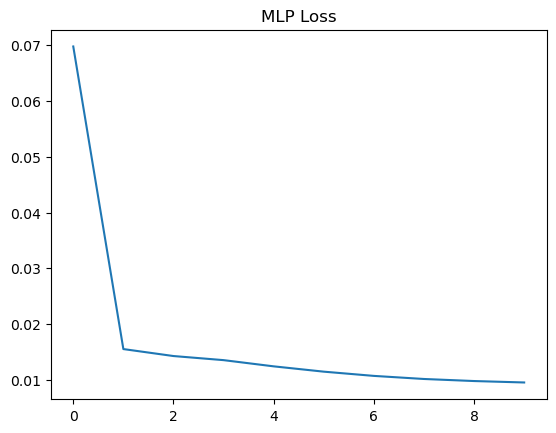

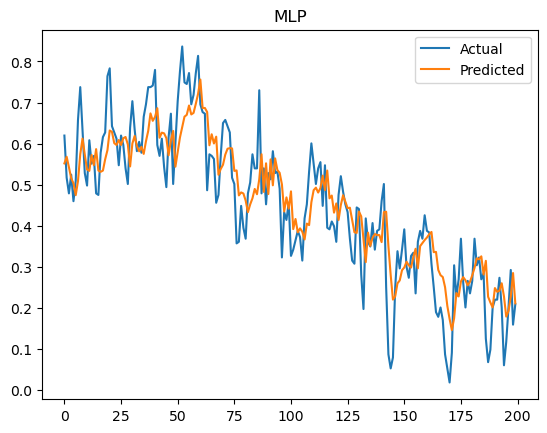


Training: GRU
Epoch 1: Loss = 0.0801
Epoch 2: Loss = 0.0146
Epoch 3: Loss = 0.0139
Epoch 4: Loss = 0.0131
Epoch 5: Loss = 0.0123
Epoch 6: Loss = 0.0116
Epoch 7: Loss = 0.0110
Epoch 8: Loss = 0.0105
Epoch 9: Loss = 0.0101
Epoch 10: Loss = 0.0099
GRU → MSE:0.0080, MAE:0.0701, RMSE:0.0895


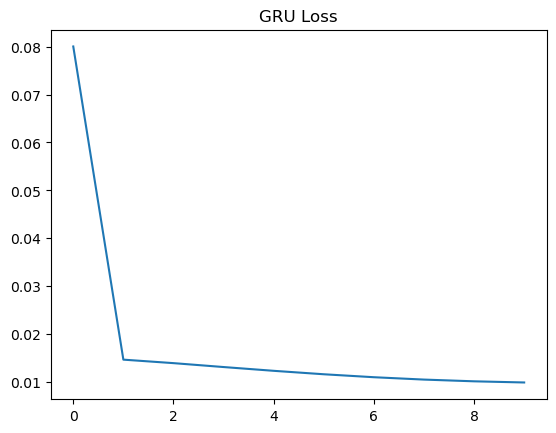

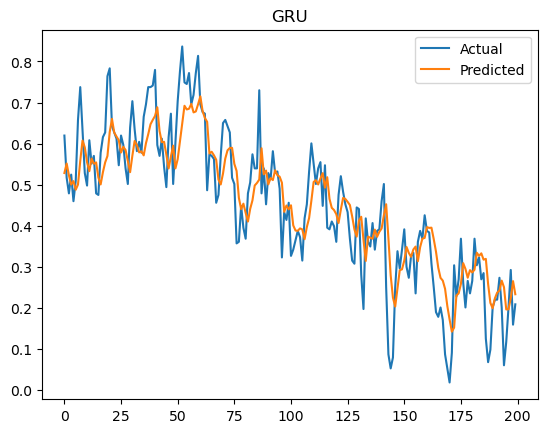


Training: LSTM
Epoch 1: Loss = 0.1020
Epoch 2: Loss = 0.0209
Epoch 3: Loss = 0.0185
Epoch 4: Loss = 0.0143
Epoch 5: Loss = 0.0114
Epoch 6: Loss = 0.0112
Epoch 7: Loss = 0.0111
Epoch 8: Loss = 0.0110
Epoch 9: Loss = 0.0109
Epoch 10: Loss = 0.0108
LSTM → MSE:0.0089, MAE:0.0735, RMSE:0.0944


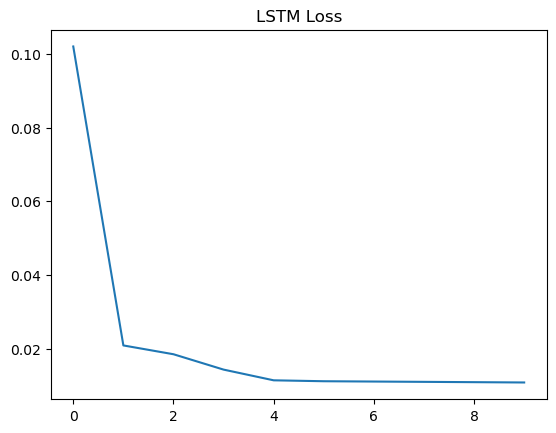

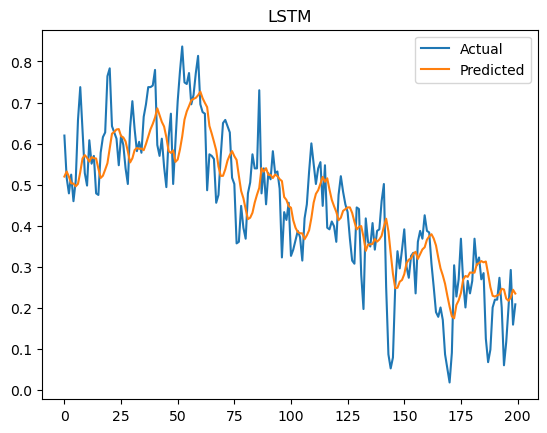


Training: Transformer
Epoch 1: Loss = 0.1572
Epoch 2: Loss = 0.0434
Epoch 3: Loss = 0.0242
Epoch 4: Loss = 0.0241
Epoch 5: Loss = 0.0241
Epoch 6: Loss = 0.0241
Epoch 7: Loss = 0.0241
Epoch 8: Loss = 0.0241
Epoch 9: Loss = 0.0241
Epoch 10: Loss = 0.0241
Transformer → MSE:0.0246, MAE:0.1292, RMSE:0.1567


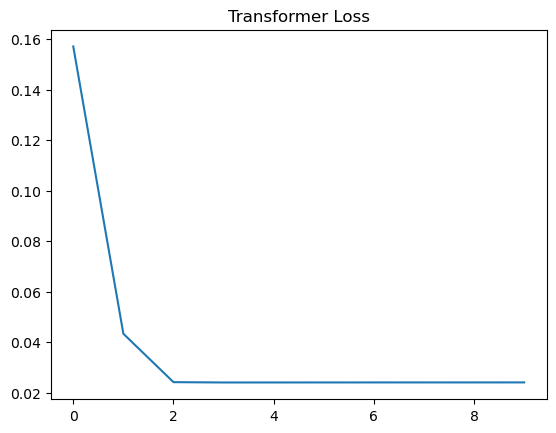

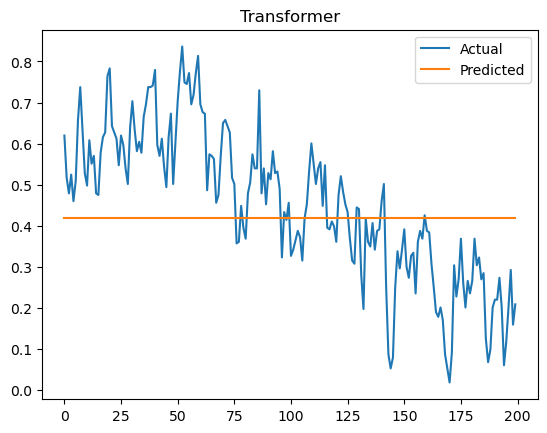


Running for window: 17

Training: MLP
Epoch 1: Loss = 0.1271


C:\Users\klpsh\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Epoch 2: Loss = 0.0130
Epoch 3: Loss = 0.0129
Epoch 4: Loss = 0.0127
Epoch 5: Loss = 0.0126
Epoch 6: Loss = 0.0124
Epoch 7: Loss = 0.0122
Epoch 8: Loss = 0.0119
Epoch 9: Loss = 0.0117
Epoch 10: Loss = 0.0115
MLP → MSE:0.0093, MAE:0.0746, RMSE:0.0966


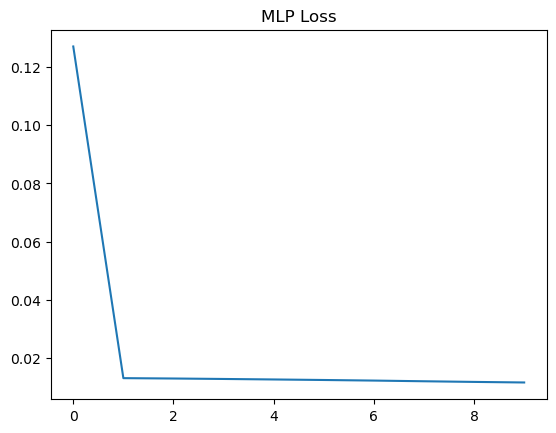

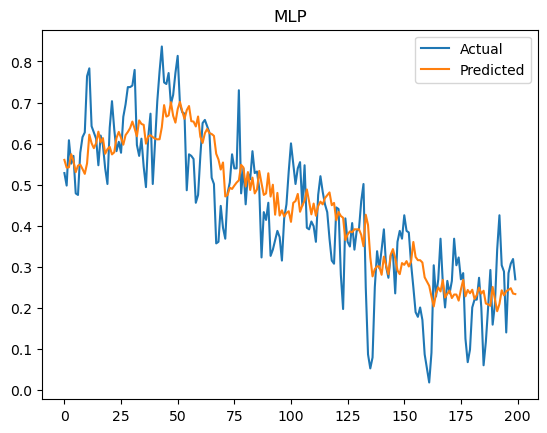


Training: GRU
Epoch 1: Loss = 0.0466
Epoch 2: Loss = 0.0183
Epoch 3: Loss = 0.0168
Epoch 4: Loss = 0.0150
Epoch 5: Loss = 0.0127
Epoch 6: Loss = 0.0106
Epoch 7: Loss = 0.0101
Epoch 8: Loss = 0.0099
Epoch 9: Loss = 0.0098
Epoch 10: Loss = 0.0097
GRU → MSE:0.0078, MAE:0.0688, RMSE:0.0884


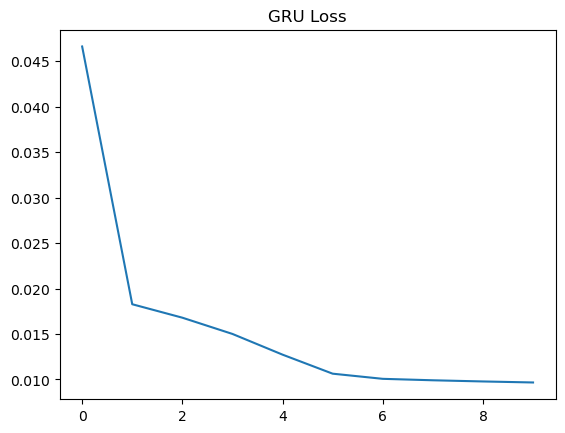

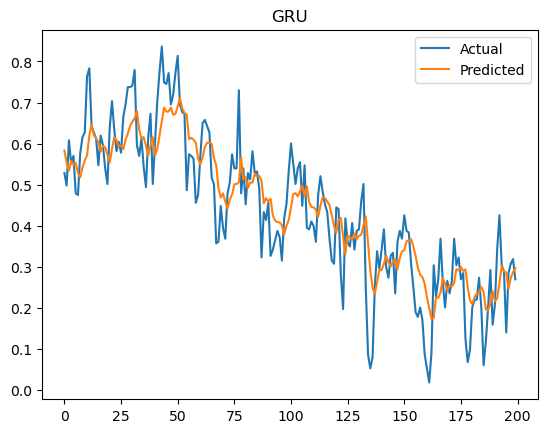


Training: LSTM
Epoch 1: Loss = 0.1421
Epoch 2: Loss = 0.0182
Epoch 3: Loss = 0.0169
Epoch 4: Loss = 0.0153
Epoch 5: Loss = 0.0136
Epoch 6: Loss = 0.0121
Epoch 7: Loss = 0.0112
Epoch 8: Loss = 0.0110
Epoch 9: Loss = 0.0109
Epoch 10: Loss = 0.0109
LSTM → MSE:0.0089, MAE:0.0733, RMSE:0.0943


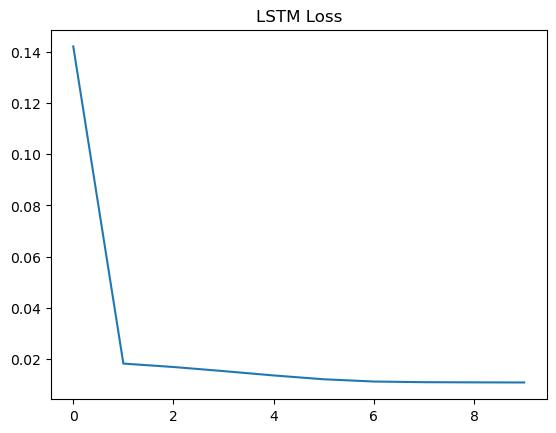

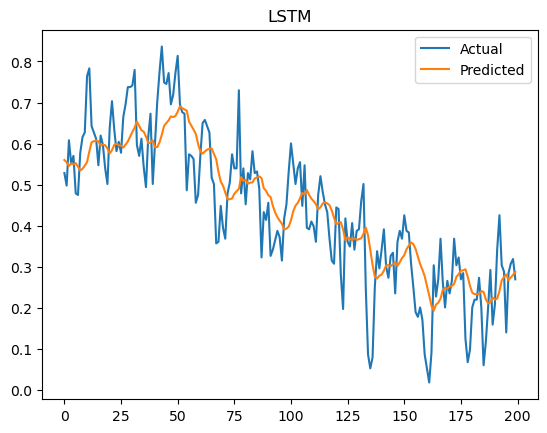


Training: Transformer
Epoch 1: Loss = 0.1040
Epoch 2: Loss = 0.0254
Epoch 3: Loss = 0.0240
Epoch 4: Loss = 0.0240
Epoch 5: Loss = 0.0240
Epoch 6: Loss = 0.0240
Epoch 7: Loss = 0.0240
Epoch 8: Loss = 0.0240
Epoch 9: Loss = 0.0240
Epoch 10: Loss = 0.0240
Transformer → MSE:0.0245, MAE:0.1288, RMSE:0.1564


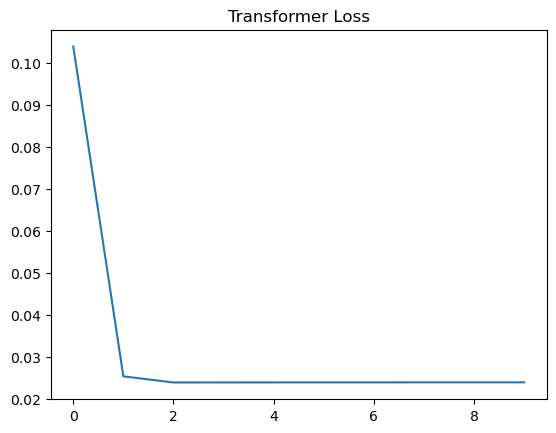

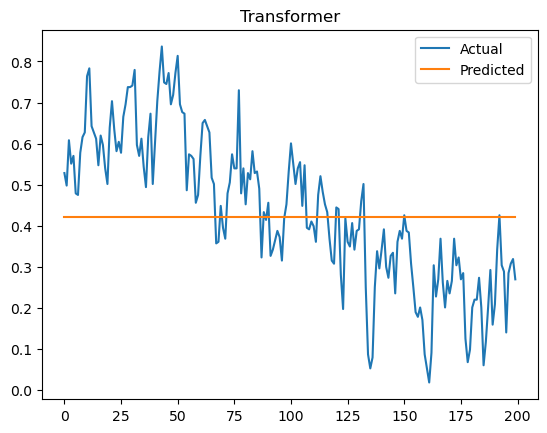


Running for window: 34

Training: MLP


C:\Users\klpsh\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Epoch 1: Loss = 0.0202
Epoch 2: Loss = 0.0155
Epoch 3: Loss = 0.0142
Epoch 4: Loss = 0.0132
Epoch 5: Loss = 0.0124
Epoch 6: Loss = 0.0118
Epoch 7: Loss = 0.0113
Epoch 8: Loss = 0.0109
Epoch 9: Loss = 0.0106
Epoch 10: Loss = 0.0104
MLP → MSE:0.0083, MAE:0.0705, RMSE:0.0912


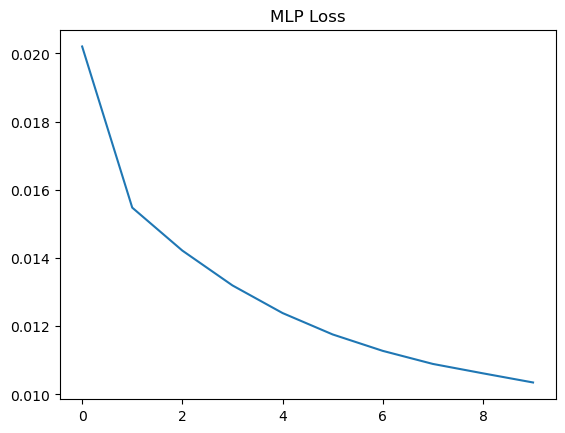

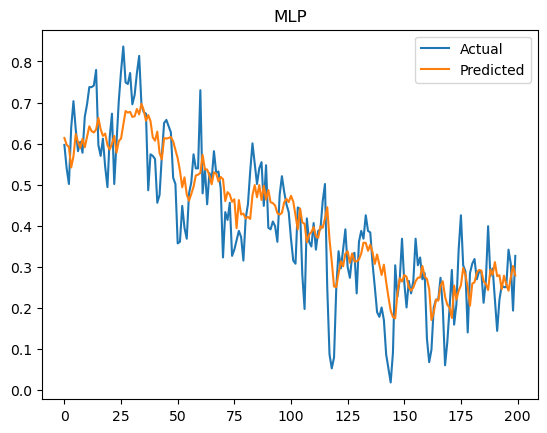


Training: GRU
Epoch 1: Loss = 0.0207
Epoch 2: Loss = 0.0133
Epoch 3: Loss = 0.0108
Epoch 4: Loss = 0.0102
Epoch 5: Loss = 0.0100
Epoch 6: Loss = 0.0099
Epoch 7: Loss = 0.0097
Epoch 8: Loss = 0.0096
Epoch 9: Loss = 0.0095
Epoch 10: Loss = 0.0094
GRU → MSE:0.0076, MAE:0.0677, RMSE:0.0872


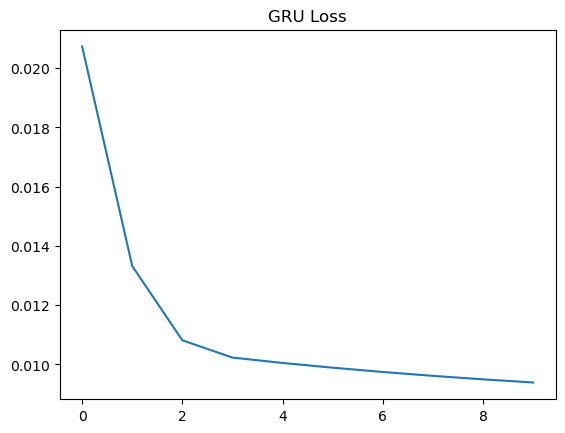

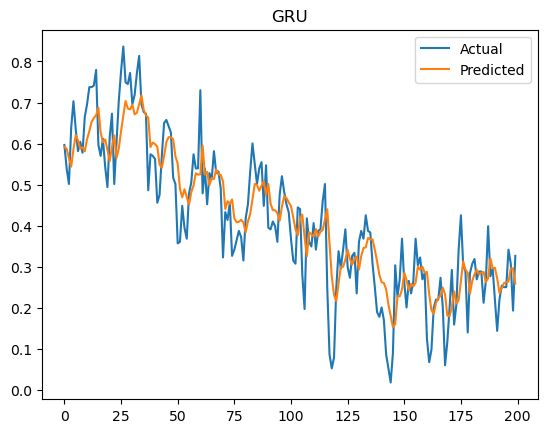


Training: LSTM
Epoch 1: Loss = 0.1458
Epoch 2: Loss = 0.0191
Epoch 3: Loss = 0.0173
Epoch 4: Loss = 0.0153
Epoch 5: Loss = 0.0130
Epoch 6: Loss = 0.0113
Epoch 7: Loss = 0.0113
Epoch 8: Loss = 0.0111
Epoch 9: Loss = 0.0109
Epoch 10: Loss = 0.0107
LSTM → MSE:0.0087, MAE:0.0723, RMSE:0.0932


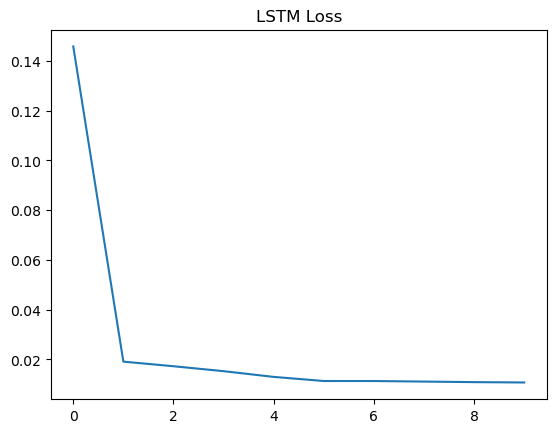

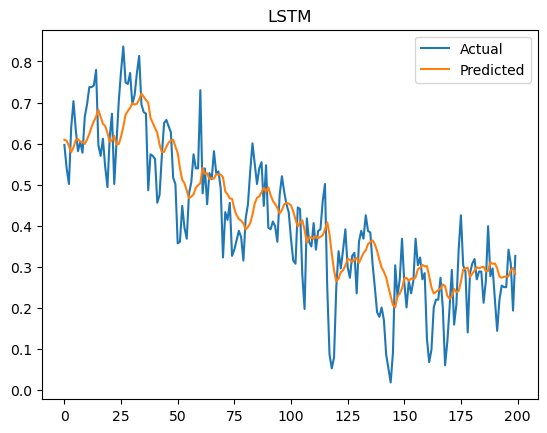


Training: Transformer
Epoch 1: Loss = 0.0708
Epoch 2: Loss = 0.0238
Epoch 3: Loss = 0.0237
Epoch 4: Loss = 0.0237
Epoch 5: Loss = 0.0237
Epoch 6: Loss = 0.0237
Epoch 7: Loss = 0.0237
Epoch 8: Loss = 0.0237
Epoch 9: Loss = 0.0237
Epoch 10: Loss = 0.0237
Transformer → MSE:0.0241, MAE:0.1278, RMSE:0.1552


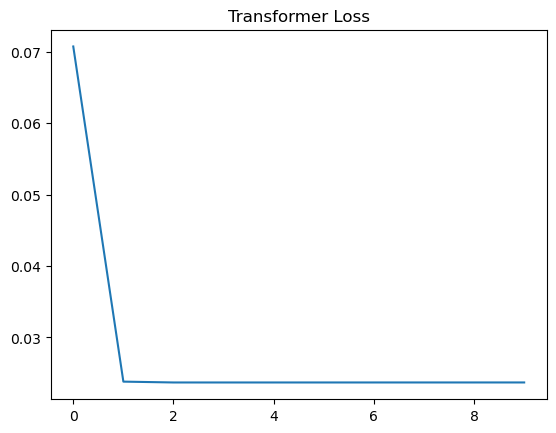

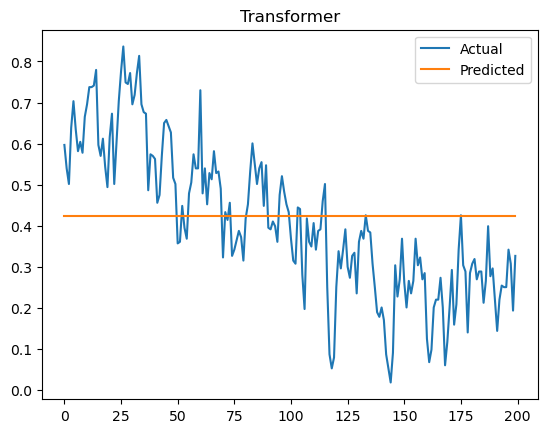

In [132]:
# ─────────────────────────────────────────────
# ABLATION STUDY
# ─────────────────────────────────────────────

windows = [
    window_size // 2,
    window_size,
    window_size * 2
]

for w in windows:
    run(w)